In [ ]:
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt
scalar = np.array(5)                  # 0-D: a single number
vector = np.array([2, 5, 1])          # 1-D: a list of numbers
matrix = np.array([[1, 2], [3, 4]])   # 2-D: rows x columns
tensor = np.ones((3, 2, 2))           # n-D: a stack of matrices
print(scalar)
print(matrix)
print(tensor)

5
[[1 2]
 [3 4]]
[[[1. 1.]
  [1. 1.]]

 [[1. 1.]
  [1. 1.]]

 [[1. 1.]
  [1. 1.]]]


In [ ]:
A = np.arange(6).reshape(2, 3)   # shape (2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())

A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


LAB EXERCISE 1 — Tensor ops: add, transpose, reshape
Using the array T provided below:

Print its ndim and shape.
Add T to itself and print the result.
Transpose T and print the new shape, then reshape T into shape (2, 6).

In [ ]:
import numpy as np
T = np.arange(12).reshape(2, 2, 3)
print("ndim =", T.ndim)
print("shape =", T.shape)
print("\nT + T:")
print(T + T)
T_transpose = T.transpose()
print("\nTransposed Tensor:")
print(T_transpose)
print("New shape =", T_transpose.shape)
T_reshape = T.reshape(2, 6)
print("\nReshaped Tensor (2,6):")
print(T_reshape)

ndim = 3
shape = (2, 2, 3)

T + T:
[[[ 0  2  4]
  [ 6  8 10]]

 [[12 14 16]
  [18 20 22]]]

Transposed Tensor:
[[[ 0  6]
  [ 3  9]]

 [[ 1  7]
  [ 4 10]]

 [[ 2  8]
  [ 5 11]]]
New shape = (3, 2, 2)

Reshaped Tensor (2,6):
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


In [ ]:
# -----------------------------------------------------------
# 🔹 2A. DOT & CROSS PRODUCTS
# -----------------------------------------------------------

a = np.array([1, 2, 3])
b = np.array([4, 0, 1])

# Dot product: sum of element-wise products -> measures alignment
print('a . b  (dot)   :', np.dot(a, b))      # 1*4 + 2*0 + 3*1 = 7

# Cross product: a new vector perpendicular to both (3-D only)
print('a x b  (cross) :', np.cross(a, b))

a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]


In [ ]:
import numpy as np

pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

def l1_norm(u):
    return np.sum(np.abs(u))

def l2_norm(u):
    return np.sqrt(np.sum(u**2))

def cosine_similarity(u, v):
    return np.dot(u, v) / (l2_norm(u) * l2_norm(v))

for i, (u, v) in enumerate(pairs, start=1):
    print(f"Pair {i}")
    print("L1 norm:", l1_norm(u))
    print("L2 norm:", l2_norm(u))
    print("Cosine similarity:", cosine_similarity(u, v))
    print()

# Pair 1 is the most similar (cosine similarity = 1.0)

Pair 1
L1 norm: 2
L2 norm: 1.4142135623730951
Cosine similarity: 0.9999999999999998

Pair 2
L1 norm: 6
L2 norm: 3.7416573867739413
Cosine similarity: 0.7142857142857143

Pair 3
L1 norm: 2
L2 norm: 2.0
Cosine similarity: 0.0



In [ ]:
import numpy as np
import scipy.linalg as la

# Square matrix A
A = np.array([[2., 1.],
              [1., 3.]])

# Identity matrix
I = np.eye(2)
print("Identity I:\n", I)

# Check inverse property
print("A @ inv(A) == I ?", np.allclose(A @ la.inv(A), I))

# Check symmetry
print("A symmetric?", np.allclose(A, A.T))

# Rotation matrix (30 degrees)
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# Check orthogonality
print("Q orthogonal?", np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? True
Q orthogonal? True


In [ ]:
# -----------------------------------------------------------
# 🔹 4A. BUILD TRANSFORMATION MATRICES
# -----------------------------------------------------------

# A unit square defined by its 4 corners (each column is a point)
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

# Scaling matrix: stretch x by 1.5, y by 0.5
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])

# Rotation matrix: rotate by 30 degrees
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ square      # apply scaling
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)

Rotated corners:
 [[ 0.         0.8660254  0.3660254 -0.5      ]
 [ 0.         0.5        1.3660254  0.8660254]]


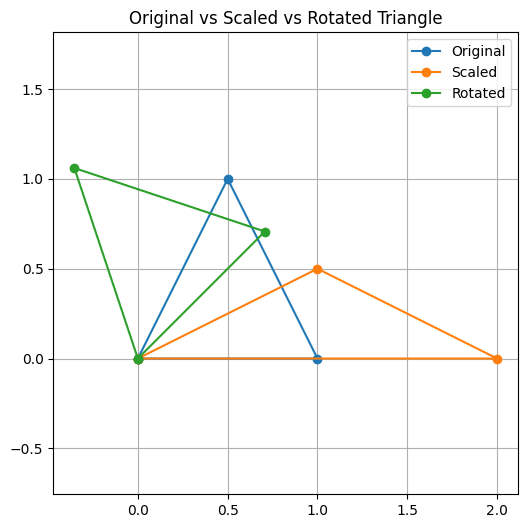

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Triangle coordinates (3 corners)
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])

# 1. Scaling matrix (x*2, y*0.5)
S = np.array([[2.0, 0.0],
              [0.0, 0.5]])

# 2. Rotation matrix (45 degrees)
theta = np.radians(45)

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# 3. Apply transformations
scaled = S @ tri
rotated = R @ tri

# Plot original triangle
plt.figure(figsize=(6,6))

plt.plot(np.append(tri[0], tri[0,0]),
         np.append(tri[1], tri[1,0]),
         marker='o',
         label='Original')

# Plot scaled triangle
plt.plot(np.append(scaled[0], scaled[0,0]),
         np.append(scaled[1], scaled[1,0]),
         marker='o',
         label='Scaled')

# Plot rotated triangle
plt.plot(np.append(rotated[0], rotated[0,0]),
         np.append(rotated[1], rotated[1,0]),
         marker='o',
         label='Rotated')

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Original vs Scaled vs Rotated Triangle")
plt.show()

In [ ]:
import numpy as np
import scipy.linalg as la

C = np.array([[4., 1.],
              [2., 3.]])

# 1. Eigenvalues and Eigenvectors
vals, vecs = la.eig(C)

# 2. Print Eigenvalues
print("Eigenvalues:", vals)

# Print Eigenvectors
print("Eigenvectors:\n", vecs)

# 3. Verify C v = lambda v for first eigenvector
v = vecs[:, 0]

lhs = C @ v
rhs = vals[0] * v

print("\nC @ v =", lhs)
print("lambda * v =", rhs)
print("Verification:", np.allclose(lhs, rhs))

Eigenvalues: [5.+0.j 2.+0.j]
Eigenvectors:
 [[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

C @ v = [3.53553391 3.53553391]
lambda * v = [3.53553391+0.j 3.53553391+0.j]
Verification: True


In [ ]:
import numpy as np
import scipy.linalg as la

# Matrix A and vector b
A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])

b = np.array([8., -11., -3.])

# Solve Ax = b
x = la.solve(A, b)

print("Solution x:", x)

# Rank of A
print("Rank of A:", la.matrix_rank(A))

if la.matrix_rank(A) == A.shape[0]:
    print("Full rank -> Unique solution exists")
else:
    print("Not full rank -> No unique solution")

# ---------------------------------------------------
# Rank Deficient Matrix
# ---------------------------------------------------

D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])

print("Rank of D:", la.matrix_rank(D))

if la.matrix_rank(D) < D.shape[0]:
    print("Rows are dependent")
else:
    print("Rows are independent")

Solution x: [ 2.  3. -1.]


AttributeError: module 'scipy.linalg' has no attribute 'matrix_rank'

In [ ]:
import numpy as np
import scipy.linalg as la

A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])

b = np.array([8., -11., -3.])

# Solve Ax = b
x = la.solve(A, b)

print("Solution x:", x)

# Rank of A
print("Rank of A:", np.linalg.matrix_rank(A))

# Rank-deficient matrix
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])

print("Rank of D:", np.linalg.matrix_rank(D))

Solution x: [ 2.  3. -1.]
Rank of A: 3
Rank of D: 2


In [ ]:
import numpy as np

# Cosine Similarity Function
def cosine(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

# Toy 4-D embeddings
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

# Cosine similarities
print("cosine(king, queen):", round(cosine(king, queen), 3))
print("cosine(king, apple):", round(cosine(king, apple), 3))

cosine(king, queen): 0.986
cosine(king, apple): 0.267


In [ ]:
import numpy as np
import scipy.linalg as la

# Cosine Similarity Function
def cosine(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

# 1. Solve the 2x2 system
A2 = np.array([[2., 1.],
               [1., 3.]])

b2 = np.array([5., 7.])

x = la.solve(A2, b2)

print("Solution x:", x)

# 2. Print rank of A2
print("Rank of A2:", np.linalg.matrix_rank(A2))

# 3. Embeddings
cat = np.array([0.8, 0.7, 0.1, 0.2])
dog = np.array([0.7, 0.8, 0.1, 0.2])
car = np.array([0.1, 0.0, 0.9, 0.8])
cat_dog = cosine(cat, dog)
cat_car = cosine(cat, car)
print("cosine(cat, dog):", round(cat_dog, 3))
print("cosine(cat, car):", round(cat_car, 3))

if cat_dog > cat_car:
    print("Cat and Dog are more similar.")
else:
    print("Cat and Car are more similar.")

Solution x: [1.6 1.8]
Rank of A2: 2
cosine(cat, dog): 0.992
cosine(cat, car): 0.251
Cat and Dog are more similar.


In [ ]:
# Core imports for the whole lab
import numpy as np
import sympy as sp

x, y = sp.symbols('x y')      # symbolic variables we'll reuse
sp.init_printing()            # pretty-print symbolic math
np.random.seed(42)
print('Setup complete. SymPy', sp.__version__, '| NumPy', np.__version__)

Setup complete. SymPy 1.14.0 | NumPy 2.0.2


In [ ]:
def g(x):
    return x**3 + 2*x

# 1. Numerical derivative at x = 2
h = 1e-6 #1*10^-6
num_deriv = (g(2 + h) - g(2)) / h
print("Numerical g'(2) =", round(num_deriv, 4))

# 2. Symbolic derivative
expr = x**3 + 2*x
sym_deriv = sp.diff(expr, x)
print("Symbolic derivative =", sym_deriv)

# 3. Evaluate symbolic derivative at x = 2
print("Symbolic g'(2) =", sym_deriv.subs(x, 2))

Numerical g'(2) = 14.0
Symbolic derivative = 3*x**2 + 2
Symbolic g'(2) = 14


In [ ]:
import sympy as sp

x, y = sp.symbols('x y')

# Function
f2 = x**2 + 3*x*y + y**2

# Partial derivative with respect to x
df_dx = sp.diff(f2, x)
print("df/dx =", df_dx)

# Partial derivative with respect to y
df_dy = sp.diff(f2, y)
print("df/dy =", df_dy)

# Gradient
grad = [df_dx, df_dy]
print("grad f =", grad)

# Evaluate gradient at (x=1, y=2)
grad_at = [g.subs({x: 1, y: 2}) for g in grad]
print("grad f at (1,2) =", grad_at)

df/dx = 2*x + 3*y
df/dy = 3*x + 2*y
grad f = [2*x + 3*y, 3*x + 2*y]
grad f at (1,2) = [8, 7]


In [ ]:
h2 = x**2 * y + sp.sin(y)

# 1. dh/dx and dh/dy
dh_dx = sp.diff(h2, x)
dh_dy = sp.diff(h2, y)

print("dh/dx =", dh_dx)
print("dh/dy =", dh_dy)

# 2. Assemble the gradient list
grad = [dh_dx, dh_dy]
print("Gradient =", grad)

# 3. Evaluate at (x=2, y=0)
grad_at = [g.subs({x: 2, y: 0}) for g in grad]
print("Gradient at (2,0) =", grad_at)

dh/dx = 2*x*y
dh/dy = x**2 + cos(y)
Gradient = [2*x*y, x**2 + cos(y)]
Gradient at (2,0) = [0, 5]


In [ ]:
import sympy as sp

x = sp.symbols('x')

# 3A. Chain Rule: y = sin(x^2)

by_hand = sp.cos(x**2) * 2*x
by_sympy = sp.diff(sp.sin(x**2), x)

print("By hand :", by_hand)
print("By SymPy:", by_sympy)
print("Match?  ", sp.simplify(by_hand - by_sympy) == 0)

# 3B. Chain Rule: y = (3x + 1)^4

expr3 = (3*x + 1)**4
print("d/dx (3x+1)^4 =", sp.diff(expr3, x))

By hand : 2*x*cos(x**2)
By SymPy: 2*x*cos(x**2)
Match?   True
d/dx (3x+1)^4 = 12*(3*x + 1)**3


In [ ]:
# y = exp(x**2 + 1)

# 1. By hand (outer derivative × inner derivative)
by_hand = sp.exp(x**2 + 1) * (2*x)

# 2. With sp.diff
by_sympy = sp.diff(sp.exp(x**2 + 1), x)

print("By hand :", by_hand)
print("By SymPy:", by_sympy)

# 3. Confirm they match
print("Match?  ", sp.simplify(by_hand - by_sympy) == 0)

By hand : 2*x*exp(x**2 + 1)
By SymPy: 2*x*exp(x**2 + 1)
Match?   True


In [ ]:
import numpy as np

# ----------------------------
# 4A. FORWARD PASS
# ----------------------------

np.random.seed(42)

X = np.random.randn(4, 3)
Y = np.random.randn(4, 1)

W1 = np.random.randn(3, 5) * 0.1
W2 = np.random.randn(5, 1) * 0.1

z1 = X @ W1
h = np.maximum(0, z1)      # ReLU
y_hat = h @ W2

loss = ((y_hat - Y) ** 2).mean()
print("Initial loss:", round(loss, 4))


# ----------------------------
# 4B. BACKWARD PASS
# ----------------------------

dy = 2 * (y_hat - Y) / Y.size
dW2 = h.T @ dy
dh = dy @ W2.T
dz1 = dh * (z1 > 0)        # ReLU gradient
dW1 = X.T @ dz1

print("dW1 shape:", dW1.shape, "(matches W1)")
print("dW2 shape:", dW2.shape, "(matches W2)")


# ----------------------------
# 4C. GRADIENT DESCENT STEP
# ----------------------------

lr = 0.1

W1 -= lr * dW1
W2 -= lr * dW2

# recompute forward pass
z1_new = X @ W1
h_new = np.maximum(0, z1_new)
y_hat_new = h_new @ W2

loss_new = ((y_hat_new - Y) ** 2).mean()

print("Loss before:", round(loss, 4))
print("Loss after :", round(loss_new, 4), "-> should be lower")

Initial loss: 1.6936
dW1 shape: (3, 5) (matches W1)
dW2 shape: (5, 1) (matches W2)
Loss before: 1.6936
Loss after : 1.6524 -> should be lower


In [ ]:
import numpy as np

np.random.seed(42)

Xb = np.random.randn(6, 4)
Yb = np.random.randn(6, 1)

Wa = np.random.randn(4, 8) * 0.1     # input -> hidden
Wb = np.random.randn(8, 1) * 0.1     # hidden -> output

# ----------------------------
# 1. Forward pass
# ----------------------------
z1 = Xb @ Wa
h = np.maximum(0, z1)
y_hat = h @ Wb

loss = ((y_hat - Yb) ** 2).mean()
print("Loss before:", round(loss, 4))

# ----------------------------
# 2. Backward pass (chain rule)
# ----------------------------
dy = 2 * (y_hat - Yb) / Yb.size
dWb = h.T @ dy
dh = dy @ Wb.T
dz1 = dh * (z1 > 0)
dWa = Xb.T @ dz1

# ----------------------------
# 3. Gradient descent step
# ----------------------------
lr = 0.05

Wa -= lr * dWa
Wb -= lr * dWb

# recompute forward pass after update
z1_new = Xb @ Wa
h_new = np.maximum(0, z1_new)
y_hat_new = h_new @ Wb

loss_new = ((y_hat_new - Yb) ** 2).mean()

print("Loss after :", round(loss_new, 4))

Loss before: 0.3798
Loss after : 0.3776


In [ ]:
import sympy as sp
import numpy as np

# ----------------------------
# 5A. HESSIAN
# ----------------------------
x, y = sp.symbols('x y')

f5 = x**2 + 3*x*y + y**2
H = sp.hessian(f5, (x, y))

print("Hessian of f:")
sp.pprint(H)


# ----------------------------
# 5B. GRADIENT DESCENT
# f(x) = (x - 4)^2
# ----------------------------

xv = 0.0          # starting point
lr = 0.2

for step in range(15):
    grad = 2 * (xv - 4)     # derivative
    xv = xv - lr * grad     # update step

print("Converged x:", round(xv, 3), "(true minimum = 4)")

Hessian of f:
⎡2  3⎤
⎢    ⎥
⎣3  2⎦
Converged x: 3.998 (true minimum = 4)


In [ ]:
import sympy as sp

x, y = sp.symbols('x y')

# ----------------------------
# 1. Hessian of f = x^4 + y^2
# ----------------------------
f = x**4 + y**2
H = sp.hessian(f, (x, y))

print("Hessian of f:")
sp.pprint(H)


# ----------------------------
# 2. Gradient Descent for f(x) = (x - 7)^2
# ----------------------------

xv = 0.0
lr = 0.1

for step in range(20):
    grad = 2 * (xv - 7)   # derivative of (x - 7)^2
    xv = xv - lr * grad   # update rule

print("Final x:", xv)

Hessian of f:
⎡    2   ⎤
⎢12⋅x   0⎥
⎢        ⎥
⎣  0    2⎦
Final x: 6.91929549467752


In [ ]:
import sympy as sp

x, y = sp.symbols('x y')

# ----------------------------
# 1. Hessian of f = x^4 + y^2
# ----------------------------
f = x**4 + y**2
H = sp.hessian(f, (x, y))

print("Hessian of f:")
sp.pprint(H)


# ----------------------------
# 2. Gradient Descent for f(x) = (x - 7)^2
# ----------------------------

xv = 0.0
lr = 0.1

for step in range(20):
    grad = 2 * (xv - 7)   # derivative of (x - 7)^2
    xv = xv - lr * grad   # update rule

print("Final x:", xv)

Hessian of f:
⎡    2   ⎤
⎢12⋅x   0⎥
⎢        ⎥
⎣  0    2⎦
Final x: 6.91929549467752


In [ ]:
import numpy as np

print("--- Intermediate NumPy Exercise ---")
print("Complete each task by writing the requested NumPy code.")
print("-----------------------------------")

# =========================
# TASK 1: ARRAY CREATION
# =========================
print("\n--- Task 1 ---")

arr1_1 = np.arange(100)
arr1_2 = np.ones((3, 3))
arr1_3 = np.full((2, 4), 7)
arr1_4 = np.random.randint(10, 51, (5, 5))

print("arr1_1 (first 10 elements):", arr1_1[:10])
print("arr1_2:\n", arr1_2)
print("arr1_3:\n", arr1_3)
print("arr1_4 (first 2 rows):\n", arr1_4[:2])

# =========================
# TASK 2: INDEXING
# =========================
print("\n--- Task 2 ---")

data = np.array([[10, 20, 30, 40],
                 [50, 60, 70, 80],
                 [90, 100, 110, 120],
                 [130, 140, 150, 160]])

val2_1 = data[1, 2]
row2_2 = data[0]
col2_3 = data[:, -1]
sub_arr2_4 = data[1:3, 0:2]
filtered_elements2_5 = data[data > 100]

print(val2_1, row2_2, col2_3)
print(sub_arr2_4)
print(filtered_elements2_5)

# =========================
# TASK 3: CONDITIONAL
# =========================
print("\n--- Task 3 ---")

arr3_1 = np.random.randint(1, 21, (4, 5))

arr3_2 = arr3_1.copy()
arr3_2[arr3_2 < 10] = 0

even_count3_3 = np.sum(arr3_1 % 2 == 0)

print(arr3_1)
print(arr3_2)
print(even_count3_3)

# =========================
# TASK 4: AGGREGATION
# =========================
print("\n--- Task 4 ---")

arr4_1 = np.array([[10, 5, 12],
                   [3, 8, 15],
                   [20, 7, 4]])

sum4_1 = np.sum(arr4_1)
mean_cols4_2 = np.mean(arr4_1, axis=0)
max_rows4_3 = np.max(arr4_1, axis=1)
std4_4 = np.std(arr4_1)

print(sum4_1)
print(mean_cols4_2)
print(max_rows4_3)
print(std4_4)

# =========================
# TASK 5: RESHAPE
# =========================
print("\n--- Task 5 ---")

arr5_1 = np.arange(24)

reshaped_arr5_2 = arr5_1.reshape(4, 6)
reshaped_arr5_3 = arr5_1.reshape(2, 3, 4)
flattened_arr5_4 = reshaped_arr5_2.ravel()

print(reshaped_arr5_2)
print(reshaped_arr5_3)
print(flattened_arr5_4)

# =========================
# TASK 6: BROADCASTING
# =========================
print("\n--- Task 6 ---")

arr6_1 = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])

scalar = 10
vector = np.array([100, 200, 300])

result6_1 = arr6_1 + scalar
result6_2 = arr6_1 + vector

print(result6_1)
print(result6_2)

# =========================
# TASK 7: COPY vs VIEW
# =========================
print("\n--- Task 7 ---")

original_arr7 = np.array([1, 2, 3, 4, 5])

view_arr7 = original_arr7[:]
view_arr7[0] = 99

copy_arr7 = original_arr7.copy()
copy_arr7[-1] = 0

print(original_arr7)
print(view_arr7)
print(copy_arr7)

# =========================
# TASK 8: STACKING
# =========================
print("\n--- Task 8 ---")

arr8_a = np.array([[1, 2], [3, 4]])
arr8_b = np.array([[5, 6], [7, 8]])
arr8_c = np.array([[9, 10]])

vstack_arr8_1 = np.vstack((arr8_a, arr8_b))
hstack_arr8_2 = np.hstack((arr8_a, arr8_b))
combined_arr8_3 = np.vstack((vstack_arr8_1, arr8_c))

# Fix: Use np.array_split for unequal division or ensure divisible number of rows
# Since combined_arr8_3 has 5 rows, it cannot be equally split into 3 parts.
# We will use np.array_split to get 3 parts, which will be of unequal sizes.
part1, part2, part3 = np.array_split(combined_arr8_3, 3)

print(vstack_arr8_1)
print(hstack_arr8_2)
print(combined_arr8_3)
print(part1, part2, part3)

# =========================
# TASK 9: SORTING
# =========================
print("\n--- Task 9 ---")

arr9_1 = np.array([5, 2, 8, 1, 9, 4, 7, 3, 6])
arr9_2d = np.array([[30, 20, 10],
                    [60, 50, 40],
                    [90, 80, 70]])

sorted_arr9_1 = np.sort(arr9_1)
sorted_cols9_2 = np.sort(arr9_2d, axis=0)
idx9_3 = np.where(arr9_1 == 9)
max_idx9_4 = np.argmax(arr9_1)

print(sorted_arr9_1)
print(sorted_cols9_2)
print(idx9_3)
print(max_idx9_4)


--- Intermediate NumPy Exercise ---
Complete each task by writing the requested NumPy code.
-----------------------------------

--- Task 1 ---
arr1_1 (first 10 elements): [0 1 2 3 4 5 6 7 8 9]
arr1_2:
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
arr1_3:
 [[7 7 7 7]
 [7 7 7 7]]
arr1_4 (first 2 rows):
 [[10 14 35 23 48]
 [36 18 24 24 35]]

--- Task 2 ---
70 [10 20 30 40] [ 40  80 120 160]
[[ 50  60]
 [ 90 100]]
[110 120 130 140 150 160]

--- Task 3 ---
[[19  2 10 13  6]
 [12 12 20 11  7]
 [ 1  1 20 13  9]
 [ 3  7  6  8  9]]
[[19  0 10 13  0]
 [12 12 20 11  0]
 [ 0  0 20 13  0]
 [ 0  0  0  0  0]]
9

--- Task 4 ---
84
[11.          6.66666667 10.33333333]
[12 15 20]
5.2493385826745405

--- Task 5 ---
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]]
[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]

--- Task 6 ---
[[11 12 13]
 [14 15 16]
 

ValueError: array split does not result in an equal division

In [ ]:
# Task 8: Stacking and Splitting (FIXED)

arr8_a = np.array([[1, 2], [3, 4]])
arr8_b = np.array([[5, 6], [7, 8]])
arr8_c = np.array([[9, 10], [11, 12]])

# Step 1: Vertical stack A and B → (4,2)
vstack_arr8_1 = np.vstack((arr8_a, arr8_b))

# Step 2: Add C → now total becomes (6,2)
combined_arr8_3 = np.vstack((vstack_arr8_1, arr8_c))

# Step 3: Now 6 rows → split into 3 equal parts (2 rows each)
part1, part2, part3 = np.split(combined_arr8_3, 3)

print("VStack:\n", vstack_arr8_1)
print("\nCombined:\n", combined_arr8_3)
print("\nPart 1:\n", part1)
print("\nPart 2:\n", part2)
print("\nPart 3:\n", part3)

VStack:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]

Combined:
 [[ 1  2]
 [ 3  4]
 [ 5  6]
 [ 7  8]
 [ 9 10]
 [11 12]]

Part 1:
 [[1 2]
 [3 4]]

Part 2:
 [[5 6]
 [7 8]]

Part 3:
 [[ 9 10]
 [11 12]]
